# HW04 Transmission Dither Locking, PDH Michelson, and FPMI
Syracuse University, Lasers and Optomechanics



In [56]:
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sympy as sp

sp.init_printing(use_latex='mathjax')

In [57]:
plt.style.use('dark_background')
fontsize = 14
mpl.rcParams.update({
    'text.usetex': False,
    'figure.figsize': (9, 6),
    'figure.autolayout': True,
    'font.family': 'serif',
    'lines.linewidth': 1.5,
    'font.size': fontsize,
    'xtick.labelsize': fontsize,
    'ytick.labelsize': fontsize,
    'legend.fontsize': fontsize,
    'legend.loc': 'best',
    'axes.edgecolor': '#b0b0b0',
    'grid.color': '#707070',
    'xtick.color': '#b0b0b0',
    'ytick.color': '#b0b0b0',
    'savefig.dpi': 80,
})

---
## Part 1: Transmitted Field Dither Locking

In class we did dither locking using the *reflected* field from a Fabry-Perot.
Can we do the same thing with the *transmitted* field?

Yes, but there's an issue with the resonance structure that makes it slightly more problematic. Initially, I kind of thought of it as something along the lines of just subtrating the incident from the refl to get the trans. But let's do this mathematically.

### 1.1: Plot E_refl and E_trans vs phase

The Fabry-Perot transfer functions (input mirror r1, t1; end mirror r2, t2):

$$E_\mathrm{refl} = \frac{-r_1 + r_2(r_1^2 + t_1^2)e^{-2i\phi}}{1 - r_1 r_2 e^{-2i\phi}} E_\mathrm{in}$$

$$E_\mathrm{trans} = \frac{t_1 t_2 e^{-i\phi}}{1 - r_1 r_2 e^{-2i\phi}} E_\mathrm{in}$$

where $\phi = kL = \omega_0 L / c$ is the single-pass phase.

Resonance happens when $e^{-2i\phi} = 1$, i.e. $\phi = n\pi$.
At resonance, $E_\mathrm{refl}$ dips to zero (for matched cavities) and $E_\mathrm{trans}$ peaks.
But the *slope* around resonance tells one which way was the drift. That's the error signal.

In [58]:
# cavity parameters
T1 = 0.3; T2 = 0.3
r1 = np.sqrt(1 - T1); t1 = np.sqrt(T1)
r2 = np.sqrt(1 - T2); t2 = np.sqrt(T2)

phi_arr = np.linspace(-np.pi/2, 3*np.pi/2, 2000)

# transfer functions (E_in = 1)
def E_refl(phi, r1, t1, r2):
    return (-r1 + r2*(r1**2 + t1**2)*np.exp(-2j*phi)) / (1 - r1*r2*np.exp(-2j*phi))

def E_trans(phi, t1, t2, r1, r2):
    return (t1*t2*np.exp(-1j*phi)) / (1 - r1*r2*np.exp(-2j*phi))

Er = E_refl(phi_arr, r1, t1, r2)
Et = E_trans(phi_arr, t1, t2, r1, r2)

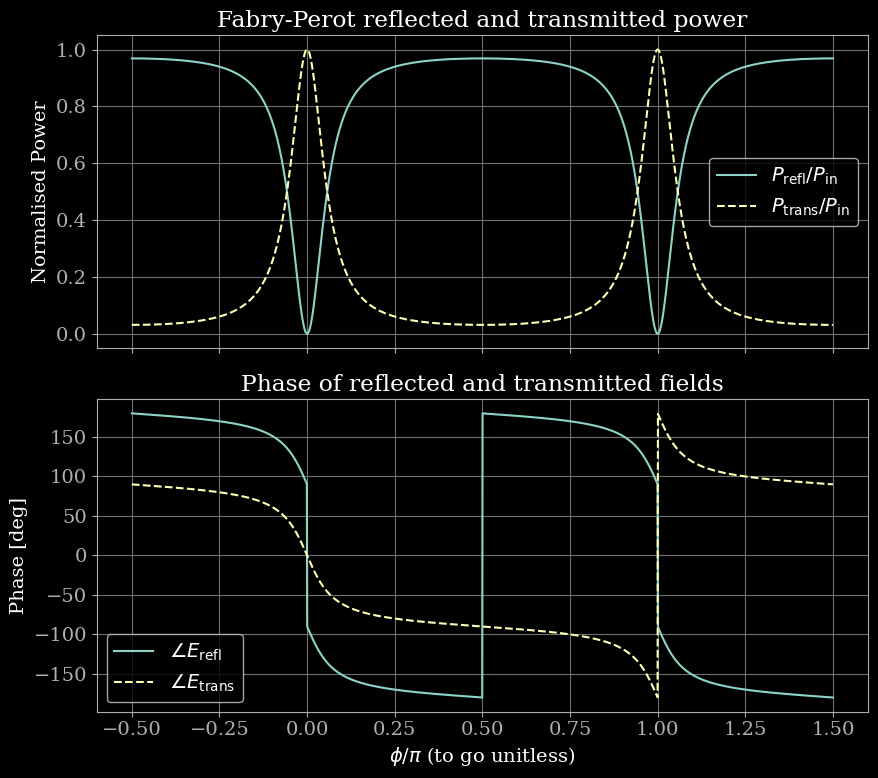

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

axes[0].plot(phi_arr/np.pi, np.abs(Er)**2, label=r'$P_\mathrm{refl}/P_\mathrm{in}$')
axes[0].plot(phi_arr/np.pi, np.abs(Et)**2, label=r'$P_\mathrm{trans}/P_\mathrm{in}$', ls='--')
axes[0].set_ylabel('Normalised Power')
axes[0].set_title('Fabry-Perot reflected and transmitted power')
axes[0].legend()
axes[0].grid()

axes[1].plot(phi_arr/np.pi, np.angle(Er, deg=True), label=r'$\angle E_\mathrm{refl}$')
axes[1].plot(phi_arr/np.pi, np.angle(Et, deg=True), label=r'$\angle E_\mathrm{trans}$', ls='--')
axes[1].set_xlabel(r'$\phi / \pi$ (to go unitless)')
axes[1].set_ylabel('Phase [deg]')
axes[1].set_title('Phase of reflected and transmitted fields')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# E_refl has a zero crossing in phase at resonance (phi = n*pi)
# E_trans also peaks at resonance but its PHASE is flat around resonance
# (it shifts by pi between resonances). This matters for the error signal.

### 1.2: E_trans with end-mirror modulation

Applying end-mirror motion $\Delta x \cos(\omega t)$, phase-modulates the round-trip:
$\phi \to \phi + \frac{\omega_0}{c} \Delta x \cos(\omega t)$

For small $\Delta x$, expand to first order in $\Delta x$:

$$E_\mathrm{trans}(t) \approx E_\mathrm{trans}(\phi) + \frac{\partial E_\mathrm{trans}}{\partial \phi} \frac{\omega_0 \Delta x}{c} \cos(\omega t)$$

Writing $\cos(\omega t) = \frac{1}{2}(e^{i\omega t} + e^{-i\omega t})$ and pulling out the carrier frequency $e^{i\omega_0 t}$:

$$E_\mathrm{trans}(t) = e^{i\omega_0 t}\left[E_0 + \frac{\omega_0 \Delta x}{2c} E_0' e^{i\omega t} + \frac{\omega_0 \Delta x}{2c} E_0' e^{-i\omega t}\right]$$

where $E_0 = E_\mathrm{trans}(\phi)$ and $E_0' = \partial E_\mathrm{trans}/\partial \phi$.

Three sidebands: carrier at $\omega_0$, and two at $\omega_0 \pm \omega$.

In [60]:
# Let's compute the derivative dE_trans/dphi
phi_s = sp.Symbol('phi', real=True)
r1_s, t1_s, r2_s, t2_s = sp.symbols('r1 t1 r2 t2', positive=True)

Et_sym = (t1_s * t2_s * sp.exp(-sp.I * phi_s)) / (1 - r1_s * r2_s * sp.exp(-2*sp.I*phi_s))
dEt_dphi = sp.diff(Et_sym, phi_s)
dEt_dphi_simplified = sp.simplify(dEt_dphi)

print('dE_trans/dphi =')
dEt_dphi_simplified

dE_trans/dphi =


        ⎛          2⋅ⅈ⋅φ⎞  ⅈ⋅φ
ⅈ⋅t₁⋅t₂⋅⎝-r₁⋅r₂ - ℯ     ⎠⋅ℯ   
──────────────────────────────
                      2       
      ⎛         2⋅ⅈ⋅φ⎞        
      ⎝r₁⋅r₂ - ℯ     ⎠        

### 1.3: Total transmitted power P_trans(t)

$$P_\mathrm{trans}(t) = |E_\mathrm{trans}(t)|^2$$

Expanding, $\Delta x^2$ terms are gone. Cross terms between carrier and sidebands give the $\omega$ oscillation. Working it out:

$$P_\mathrm{trans}(t) = |E_0|^2 + \frac{\omega_0 \Delta x}{c} \mathrm{Re}\left[E_0^* E_0'\right] \cos(\omega t)
+ \frac{\omega_0 \Delta x}{c} \mathrm{Im}\left[E_0^* E_0'\right] \sin(\omega t)$$

DC term is just the usual transmitted power. The $\omega$ terms are the new error signal.

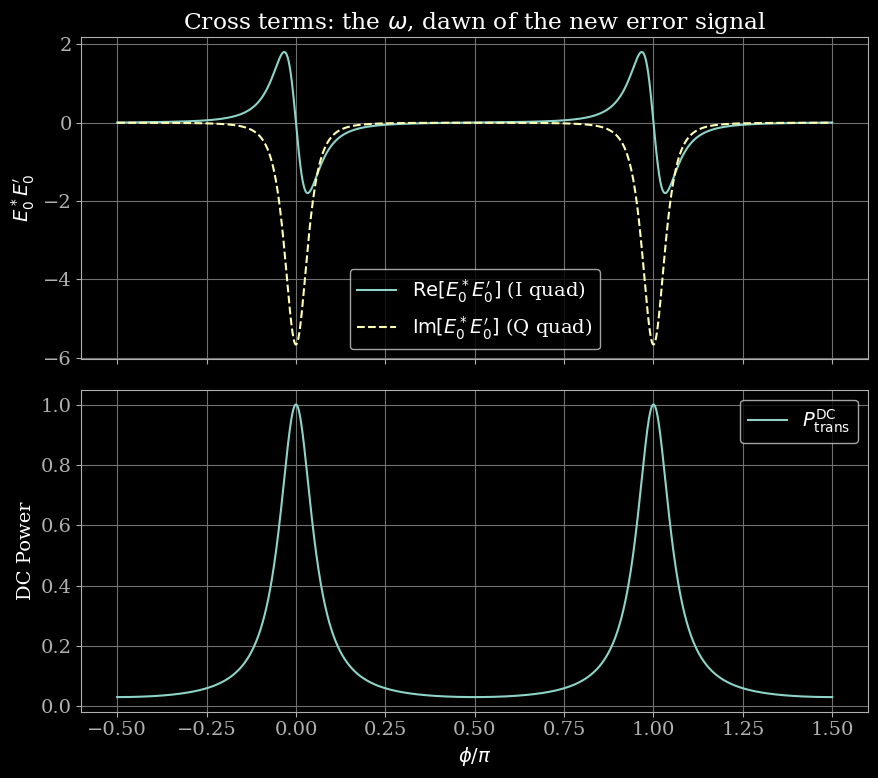

In [104]:
# Numerically verify: compute P_trans and its derivative
dEt_dphi_num = np.gradient(Et, phi_arr)

# The 1-omega term in P_trans is 2*Re(E0* * dE0/dphi) * (w0*Dx/c) * cos(wt)
#                            + 2*Im(E0* * dE0/dphi) * (w0*Dx/c) * sin(wt)
cross = np.conj(Et) * dEt_dphi_num

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

axes[0].plot(phi_arr/np.pi, np.real(cross), label=r'$\mathrm{Re}[E_0^* E_0^\prime]$ (I quad)')
axes[0].plot(phi_arr/np.pi, np.imag(cross), label=r'$\mathrm{Im}[E_0^* E_0^\prime]$ (Q quad)', ls='--')
axes[0].set_ylabel(r'$E_0^* E_0^\prime$')
axes[0].set_title(r'Cross terms: the $\omega$, dawn of the new error signal')
axes[0].legend()
axes[0].grid()

axes[1].plot(phi_arr/np.pi, np.abs(Et)**2, label=r'$P_\mathrm{trans}^\mathrm{DC}$')
axes[1].set_xlabel(r'$\phi / \pi$')
axes[1].set_ylabel('DC Power')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

### 1.4: Demodulated transmitted power at omega

Demodulate by multiplying by $\cos(\omega t)$ and $\sin(\omega t)$ then integrating over one cycle.

$$P_\mathrm{trans}^I(\omega) = \frac{\omega_0 \Delta x}{c} \mathrm{Re}[E_0^* E_0']$$

$$P_\mathrm{trans}^Q(\omega) = \frac{\omega_0 \Delta x}{c} \mathrm{Im}[E_0^* E_0']$$

So:
$$\frac{P_\mathrm{trans}(\omega)}{\Delta x} = \frac{\omega_0}{c} E_0^* E_0'$$

The I quadrature gives the real part, Q gives the imaginary part.
At resonance, $E_0'$ is purely imaginary (the derivative of the transmitted field flips sign),
so the signal lands mostly in Q. This is the key difference from the reflected-field case.

### 1.5:Phase sweep of P_trans(omega)/Dx

Cavity parameters: L=1m, Pin=1W, T1=T2=0.3, lambda=1064nm, f=100Hz.

Note: since $\omega/(2\pi) = 100$ Hz is tiny compared to the FSR ($c/2L \approx 150$ MHz),
the sideband phase from propagation is negligible. The derivative is just the
static derivative of $E_\mathrm{trans}$ with respect to $\phi$.

In [105]:
# parameters
c = 3e8
lam = 1064e-9
omega0 = 2*np.pi * c / lam
L = 1.0
Pin = 1.0
T1 = 0.3; T2 = 0.3
r1 = np.sqrt(1 - T1); t1 = np.sqrt(T1)
r2 = np.sqrt(1 - T2); t2 = np.sqrt(T2)
f_mod = 100.0
omega_mod = 2*np.pi * f_mod

phi_sweep = np.linspace(-np.pi/2, 3*np.pi/2, 5000)

Et_sweep = E_trans(phi_sweep, t1, t2, r1, r2)
# numerical derivative w.r.t. phi
dEt_sweep = np.gradient(Et_sweep, phi_sweep)

# demodulated signal (normalised by Delta_x)
# P_trans(omega)/Delta_x = (omega0/c) * E0* E0'
TF_trans = (omega0 / c) * np.conj(Et_sweep) * dEt_sweep

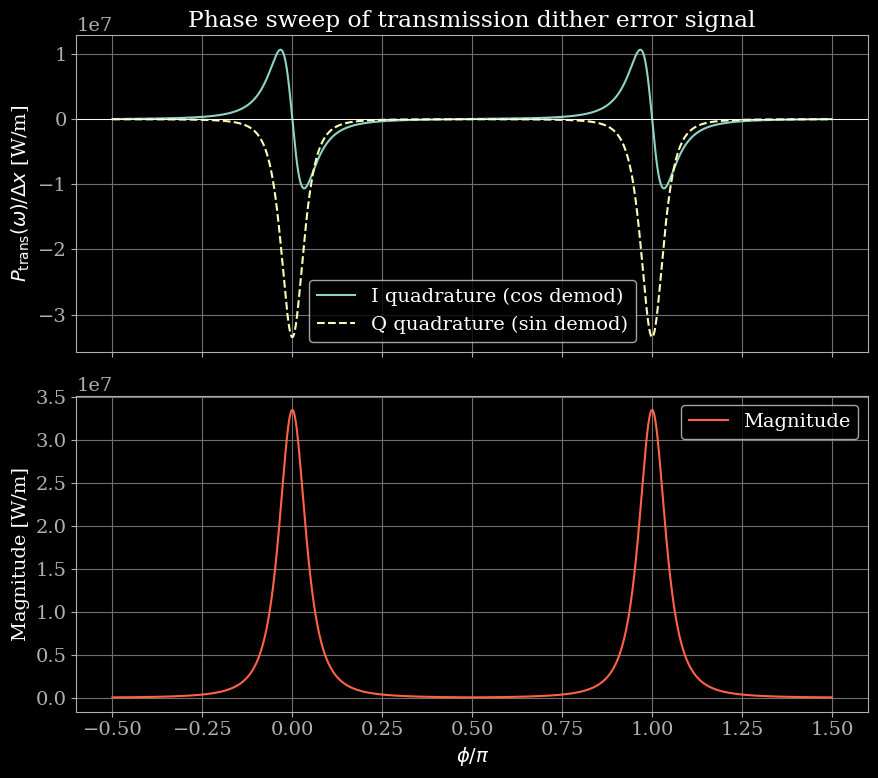

In [106]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

axes[0].plot(phi_sweep/np.pi, np.real(TF_trans), label='I quadrature (cos demod)')
axes[0].plot(phi_sweep/np.pi, np.imag(TF_trans), label='Q quadrature (sin demod)', ls='--')
axes[0].axhline(0, color='w', lw=0.7)
axes[0].set_ylabel(r'$P_\mathrm{trans}(\omega) / \Delta x$ [W/m]')
axes[0].set_title(r'Phase sweep of transmission dither error signal')
axes[0].legend()
axes[0].grid()

axes[1].plot(phi_sweep/np.pi, np.abs(TF_trans), color='tomato', label='Magnitude')
axes[1].set_xlabel(r'$\phi / \pi$')
axes[1].set_ylabel('Magnitude [W/m]')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# the error signal (Q quad) is zero AT resonance (phi = n*pi)
# and has opposite sign on either side, so usable zero crossing for locking
# But the signal is purely Q (imaginary) at resonance, unlike reflection dither
# which has the signal in I near resonance.

### 1.6: Transfer function vs frequency at phi = 1 deg

Now, sweep frequency instead of phase. At a fixed small offset $\phi = 1°$ from resonance,
the sideband starts to matter. The cavity acts as a low-pass filter with pole at the
linewidth $f_\mathrm{pole} = c T_1 / (4\pi L)$.

Above the pole frequency, the sideband can no longer build up inside the cavity,
and the error signal rolls off.

In [107]:
phi_lock = 1.0 * np.pi/180  # 1 degree offset from resonance

f_arr = np.logspace(3, 8.5, 3000)
omega_arr = 2*np.pi * f_arr

# carrier
E0 = E_trans(phi_lock, t1, t2, r1, r2)

# sideband transfer functions at omega_0 +/- omega
# each sideband accumulates phi +/- omega*L/c extra single-pass phase
phi_usb = phi_lock + omega_arr * L / c
phi_lsb = phi_lock - omega_arr * L / c

Et_usb = E_trans(phi_usb, t1, t2, r1, r2)
Et_lsb = E_trans(phi_lsb, t1, t2, r1, r2)

# the demodulated signal at omega:
# P_trans^I + i P_trans^Q = E0*.Et_usb + E0*.Et_lsb* (schematically)
# (proper derivation gives cross terms between carrier and each sideband)
TF_freq = np.conj(E0) * Et_usb + E0 * np.conj(Et_lsb)
TF_freq_scaled = TF_freq * (omega0 / c)

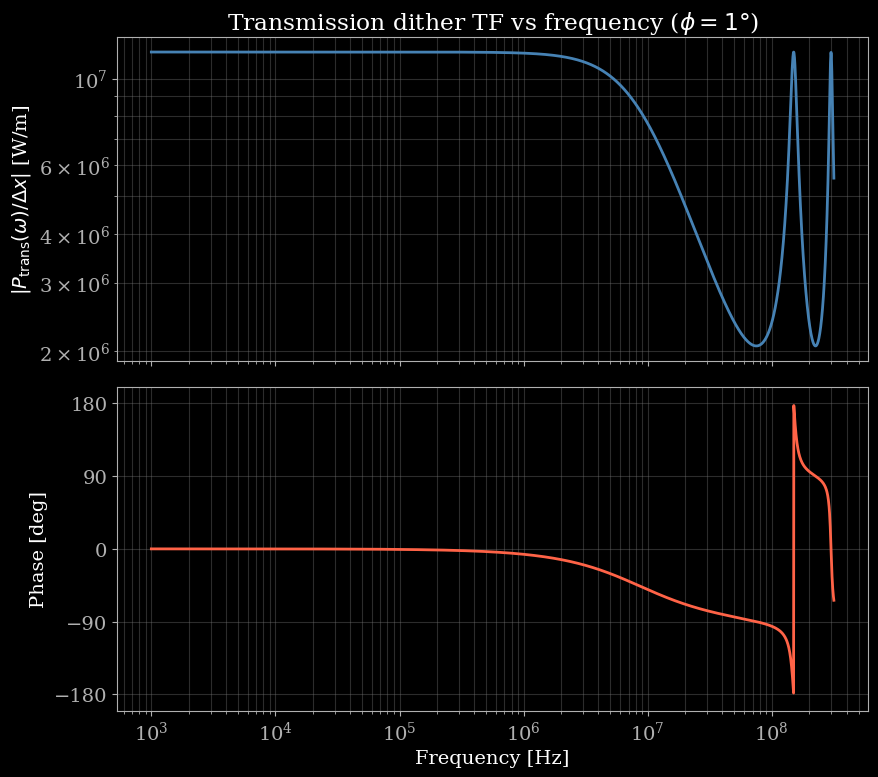

Cavity pole ~ 7.16e+06 Hz


In [108]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax1.loglog(f_arr, np.abs(TF_freq_scaled), color='steelblue', lw=2)
ax1.set_ylabel(r'$|P_\mathrm{trans}(\omega)/\Delta x|$ [W/m]')
ax1.set_title(r'Transmission dither TF vs frequency ($\phi = 1°$)')
ax1.grid(which='both', alpha=0.4)

ax2.semilogx(f_arr, np.angle(TF_freq_scaled, deg=True), color='tomato', lw=2)
ax2.set_ylabel('Phase [deg]')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(-200, 200)
ax2.set_yticks([-180, -90, 0, 90, 180])
ax2.grid(which='both', alpha=0.4)

plt.tight_layout()
plt.show()

# Pole frequency (cavity linewidth / 2)
f_pole = c * T1 / (4 * np.pi * L)
print(f'Cavity pole ~ {f_pole:.2e} Hz')
# Above this frequency the error signal rolls off; same as reflection dither

---
## Part 2: PDH Michelson

Now we do PDH on a Michelson. Instead of dithering a mirror, we inject RF phase sidebands
at the input(kinda similar). The carrier sees the dark fringe; the sidebands, being at a different frequency,
will generally NOT be on the dark fringe! They carry information about the carrier offset.

This is the same idea as PDH for a Fabry-Perot, just applied to the Michelson dark port.

Setup: EOM creates sidebands at $\omega_0 \pm \Omega$. Carrier differential phase:
$\phi_d = \omega_0 (L_x - L_y)/c$. Sideband differential phase: $\varphi_d = \Omega (L_x - L_y)/c$.

### 2.1: Dark port field E_as(t)

The input field with phase modulation at depth $\Gamma$:
$$E_\mathrm{in}(t) = E_0 e^{i\omega_0 t} e^{i\Gamma \sin(\Omega t)}
\approx E_0 e^{i\omega_0 t}\left[1 + \frac{\Gamma}{2}e^{i\Omega t} - \frac{\Gamma}{2}e^{-i\Omega t}\right]$$

Each frequency component sees the Michelson differently. For a frequency $\omega$, the differential phase is
$\phi_d(\omega) = \omega(L_x - L_y)/(2c)$.

So with $r_x = r_y = 1$ and ideal BS:

$$\frac{E_\mathrm{as}}{E_\mathrm{in}}(\omega_0) = i e^{-2i\phi_c} \sin(2\phi_d)$$

$$\frac{E_\mathrm{as}}{E_\mathrm{in}}(\omega_0 + \Omega) = i e^{-2i(\phi_c + \delta\phi_c)} \sin(2(\phi_d + \varphi_d))$$

$$\frac{E_\mathrm{as}}{E_\mathrm{in}}(\omega_0 - \Omega) = i e^{-2i(\phi_c - \delta\phi_c)} \sin(2(\phi_d - \varphi_d))$$

where $\delta\phi_c = \Omega(L_x + L_y)/(2c)$ is the tiny common-mode sideband phase.

So the full dark port field is:
$$E_\mathrm{as}(t) = i E_0 e^{i\omega_0 t} e^{-2i\phi_c}\left[
\sin(2\phi_d) + \frac{\Gamma}{2}e^{i\Omega t} e^{-2i\delta\phi_c}\sin(2(\phi_d+\varphi_d))
- \frac{\Gamma}{2}e^{-i\Omega t} e^{2i\delta\phi_c}\sin(2(\phi_d-\varphi_d))\right]$$

If $L_x = L_y$: $\phi_d = 0$, $\varphi_d = 0$, so ALL terms vanish, giving us no signal. A perfectly symmetric Michelson sends everything back to the bright port.

### 2.2: Dark power P_as(t)

Computing $P_\mathrm{as} = |E_\mathrm{as}|^2$, can drop $\Gamma^2$ terms.

Cross terms between carrier and sidebands give the $\Omega$ oscillation:

$$P_\mathrm{as}(t) = \sin^2(2\phi_d)
+ \Gamma \sin(2\phi_d)\left[\sin(2(\phi_d+\varphi_d)) - \sin(2(\phi_d-\varphi_d))\right]\cos(\Omega t) + \ldots$$

Using the trig identity $\sin(A+B) - \sin(A-B) = 2\cos(A)\sin(B)$:

$$P_\mathrm{as}(t) = \sin^2(2\phi_d) + 2\Gamma \sin(2\phi_d)\cos(2\phi_d)\sin(2\varphi_d)\cos(\Omega t) + \ldots$$

Dropping the imaginary/sin(Omega t) term (it's zero at this order with equal arms):

$$\frac{P_\mathrm{as}}{\Gamma}(\Omega) = \sin(4\phi_d) \sin(2\varphi_d)$$

This is the PDH error signal for the Michelson.

### 2.3: Demodulated signal- phase sweep

$$\frac{P_\mathrm{as}}{\Gamma}(\phi_d, \varphi_d) = \sin(4\phi_d) \sin(2\varphi_d)$$

Parameters: $L_x = L_y = 5$ m, $\Omega = 2\pi \times 10$ MHz.


 For *equal* arms, $\varphi_d = 0$ and the whole signal vanishes. The PDH Michelson's arm's signals work for *asymmetric* arm lengths.

 The whole signal comes from the common-mode sideband phase $\delta\phi_c = \Omega(L_x+L_y)/(2c)$, not $\varphi_d$.

m: $\delta\phi_c = \Omega \times 5/c$. 

The error signal becomes:

$$\frac{P_\mathrm{as}}{\Gamma} = 2\sin(2\phi_d) \cos(2(\phi_d + \delta\phi_c))\sin(2\delta\phi_c) \approx \sin(4\phi_d)\sin(2\delta\phi_c)$$

So it's $\phi_d$ that we scan, and $\delta\phi_c$ sets the sensitivity.
As we increase $\phi_d$ off resonance, the signal grows then oscillates. It doesn't stay
as a simple linear error signal the way PDH does for Fabry-Perot.

In [109]:
c = 3e8
lam = 1064e-9
omega0_pdh = 2*np.pi * c / lam

Lx = 5.0; Ly = 5.0
Omega = 2*np.pi * 10e6

# common-mode sideband phase (half-round-trip in each arm)
delta_phi_c = Omega * (Lx + Ly) / (2 * c)
# differential sideband phase (zero for equal arms)
phi_d_RF = Omega * (Lx - Ly) / (2 * c)

print(f'delta_phi_c = {delta_phi_c:.4f} rad')
print(f'phi_d_RF = {phi_d_RF:.4f} rad')

phi_d_arr = np.linspace(-5*np.pi, 5*np.pi, 5000)

# full demodulated signal:
# P_as/Gamma = sin(2*phi_d) * [sin(2(phi_d + varphi_d)) - sin(2(phi_d - varphi_d))]
# with phi_d_RF = 0, this reduces to 2*sin(2*phi_d)*cos(2*phi_d)*sin(2*delta_phi_c)
# = sin(4*phi_d) * sin(2*delta_phi_c)
PDH_mich = np.sin(4 * phi_d_arr) * np.sin(2 * delta_phi_c)

delta_phi_c = 1.0472 rad
phi_d_RF = 0.0000 rad


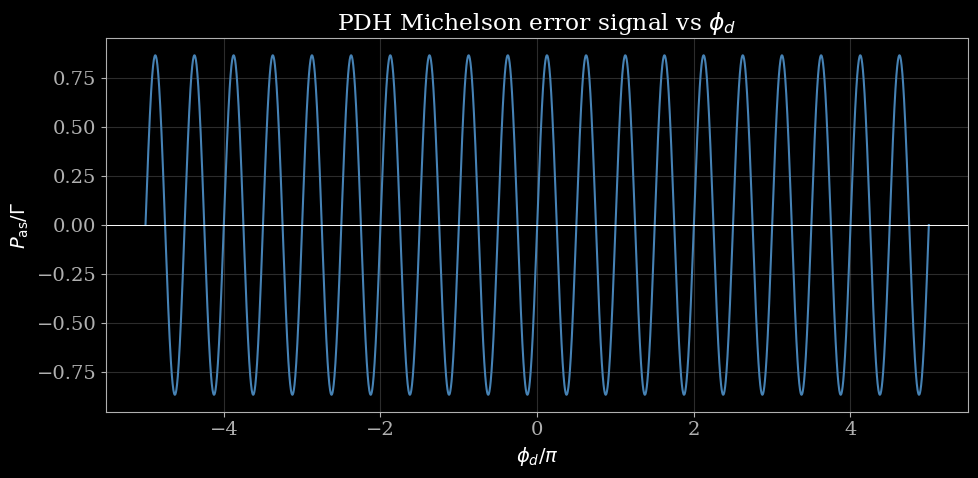

In [110]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(phi_d_arr/np.pi, PDH_mich, color='steelblue', lw=1.5)
ax.axhline(0, color='w', lw=0.7)
ax.set_xlabel(r'$\phi_d / \pi$')
ax.set_ylabel(r'$P_\mathrm{as}/\Gamma$')
ax.set_title(r'PDH Michelson error signal vs $\phi_d$')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# The signal oscillates as sin(4*phi_d), so, there are many zero crossings.
# Only the ones near phi_d = 0 (dark fringe) are useful for locking.
# As phi_d increases, we sweep through more and more fringes.
# Unlike a Fabry-Perot, the Michelson has no high-finesse resonance, not gibing
#a sharp point to l0ock at.

---
## Part 3: Fabry-Perot Michelson Interferometer (FPMI)

This is essentially LIGO's basic topology. Instead of single end mirrors,
each Michelson arm is a Fabry-Perot cavity (ITM + ETM).

The FP cavity enhances the phase sensitivity by storing the light
for many bounces. The effective reflectivity of each arm becomes the FP reflectivity
$r_\mathrm{FP}(\Phi)$, which near resonance has a steep phase slope.



### 3.1 : Adjacency Matrix for FPMI

Fields in the system (one side only, by symmetry):
- $E_1$: input
- $E_2$: at Michelson BS
- $E_3$: in X short arm (length $\ell_x$), heading to ITM_x
- $E_4$: in Y short arm (length $\ell_y$), heading to ITM_y
- $E_5$: inside X FP cavity, heading to ETM_x (after ITM_x)
- $E_6$: inside Y FP cavity, heading to ETM_y (after ITM_y)
- $E_7$: reflected from ETM_x, heading back to ITM_x
- $E_8$: reflected from ETM_y, heading back to ITM_y
- $E_9$: exiting X FP cavity (reflected from ITM_x back toward BS)
- $E_{10}$: exiting Y FP cavity (reflected from ITM_y back toward BS)
- $E_{11}$: antisymmetric port



In [111]:
# Display the symbolic adjacency matrix structure
# (use sympy for readability, then solve numerically)
import sympy as sp

phi_x_s, phi_y_s = sp.symbols('phi_x phi_y', real=True)
Phi_x_s, Phi_y_s = sp.symbols('Phi_x Phi_y', real=True)
r_bs_s, t_bs_s   = sp.symbols('r_bs t_bs', positive=True)
r_itmx_s, t_itmx_s, r_etmx_s = sp.symbols('r_itmx t_itmx r_etmx', positive=True)
r_itmy_s, t_itmy_s, r_etmy_s = sp.symbols('r_itmy t_itmy r_etmy', positive=True)

M_sym = sp.zeros(11, 11)

# E2 = t_bs * E1
M_sym[1, 0] = t_bs_s
# E3 = t_bs * e^{-i phi_x} * E2
M_sym[2, 1] = t_bs_s * sp.exp(-sp.I * phi_x_s)
# E4 = -r_bs * e^{-i phi_y} * E2
M_sym[3, 1] = -r_bs_s * sp.exp(-sp.I * phi_y_s)
# E5 = t_itmx * e^{-i Phi_x} * E3 + r_itmx * e^{-2i Phi_x} * E7 (cavity round-trip)
M_sym[4, 2] = t_itmx_s * sp.exp(-sp.I * Phi_x_s)
M_sym[4, 6] = r_itmx_s * sp.exp(-2*sp.I * Phi_x_s)
# E6 = t_itmy * e^{-i Phi_y} * E4 + r_itmy * e^{-2i Phi_y} * E8
M_sym[5, 3] = t_itmy_s * sp.exp(-sp.I * Phi_y_s)
M_sym[5, 7] = r_itmy_s * sp.exp(-2*sp.I * Phi_y_s)
# E7 = -r_etmx * E5
M_sym[6, 4] = -r_etmx_s
# E8 = -r_etmy * E6
M_sym[7, 5] = -r_etmy_s
# E9 = -r_itmx * e^{-i Phi_x} * E3 + t_itmx * e^{-2i Phi_x} * E7
M_sym[8, 2] = -r_itmx_s * sp.exp(-sp.I * Phi_x_s)
M_sym[8, 6] =  t_itmx_s * sp.exp(-2*sp.I * Phi_x_s)
# E10 = -r_itmy * e^{-i Phi_y} * E4 + t_itmy * e^{-2i Phi_y} * E8
M_sym[9, 3] = -r_itmy_s * sp.exp(-sp.I * Phi_y_s)
M_sym[9, 7] =  t_itmy_s * sp.exp(-2*sp.I * Phi_y_s)
# E11 = r_bs * e^{-i phi_x} * E9 + t_bs * e^{-i phi_y} * E10
M_sym[10, 8] = r_bs_s * sp.exp(-sp.I * phi_x_s)
M_sym[10, 9] = t_bs_s * sp.exp(-sp.I * phi_y_s)

M_sym

⎡ 0          0              0               0           0        0           0 ↪
⎢                                                                              ↪
⎢t_bs        0              0               0           0        0           0 ↪
⎢                                                                              ↪
⎢             -ⅈ⋅φₓ                                                            ↪
⎢ 0     t_bs⋅ℯ              0               0           0        0           0 ↪
⎢                                                                              ↪
⎢             -ⅈ⋅φ_y                                                           ↪
⎢ 0    -r_bs⋅ℯ              0               0           0        0           0 ↪
⎢                                                                              ↪
⎢                            -ⅈ⋅Φₓ                                             ↪
⎢ 0          0        tᵢₜₘₓ⋅ℯ               0           0        0     rᵢₜₘₓ⋅ℯ ↪
⎢                           

### 3.2: E_as/E_in via compound interferometer

The FP cavity reflectivity (input mirror r_itm, t_itm; end mirror r_etm, t_etm):

$$r_\mathrm{FP}(\Phi) = \frac{-r_\mathrm{itm} + r_\mathrm{etm}(r_\mathrm{itm}^2 + t_\mathrm{itm}^2)e^{-2i\Phi}}{1 - r_\mathrm{itm} r_\mathrm{etm} e^{-2i\Phi}}$$

Substitute $r_x \to r_\mathrm{FP}(\Phi_x)$, $r_y \to r_\mathrm{FP}(\Phi_y)$ into the Michelson formula.
The short-arm phase $\phi_x$, $\phi_y$ enters as an overall phase that doesn't affect the
differential signal (set to 0 as per the simplifications).

With ideal BS and balanced arms ($r_\mathrm{itmx} = r_\mathrm{itmy}$, $r_\mathrm{etmx} = r_\mathrm{etmy}$):

$$\frac{E_\mathrm{as}}{E_\mathrm{in}} = i e^{-2i\Phi_c} \sin(2\phi_d^\mathrm{FP})$$

where $\phi_d^\mathrm{FP}$ is the *phase* of $r_\mathrm{FP}(\Phi_d)$. So, the FP cavity gives a
much steeper phase response near resonance than a single mirror.

In [112]:
# FP reflectivity
def r_FP(Phi, r_itm, t_itm, r_etm):
    num = -r_itm + r_etm * (r_itm**2 + t_itm**2) * np.exp(-2j*Phi)
    den = 1 - r_itm * r_etm * np.exp(-2j*Phi)
    return num / den

# cavity parameters
ell = 5.0      # short Michelson arm [m]
L_FP = 4000.0  # FP arm length [m]
T_itm = 0.10   # 10% transmission
T_etm = 0.0    # perfect end mirror
r_itm = np.sqrt(1 - T_itm)
t_itm = np.sqrt(T_itm)
r_etm = np.sqrt(1 - T_etm)  # = 1

c = 3e8
lam_fpmi = 1064e-9
omega0_fpmi = 2*np.pi * c / lam_fpmi

# sweep differential FP phase
Phi_d_arr = np.linspace(-2*np.pi, 2*np.pi, 5000)

# For comparison: plain Michelson (r_x = r_y = 1)
Eas_mich = 1j * np.sin(2 * Phi_d_arr)

# FPMI: replace r_x, r_y with r_FP
# E_as/E_in = (r_bs*t_bs) * r_FP(Phi_d) - (r_bs*t_bs) * r_FP(-Phi_d)
# = i * e^{-2i Phi_c} * sin(2 * angle(r_FP)) * |r_FP|
# For the differential scan, Phi_c = 0 and we scan Phi_d
rFP_x = r_FP(Phi_d_arr, r_itm, t_itm, r_etm)
rFP_y = r_FP(-Phi_d_arr, r_itm, t_itm, r_etm)

# Full FPMI AS field (ideal BS: r_bs=t_bs=1/sqrt(2))
# E_as = r_bs*t_bs*(r_FP(x) - r_FP(y)) (up to common phase)
Eas_fpmi = 0.5 * (rFP_x - rFP_y)

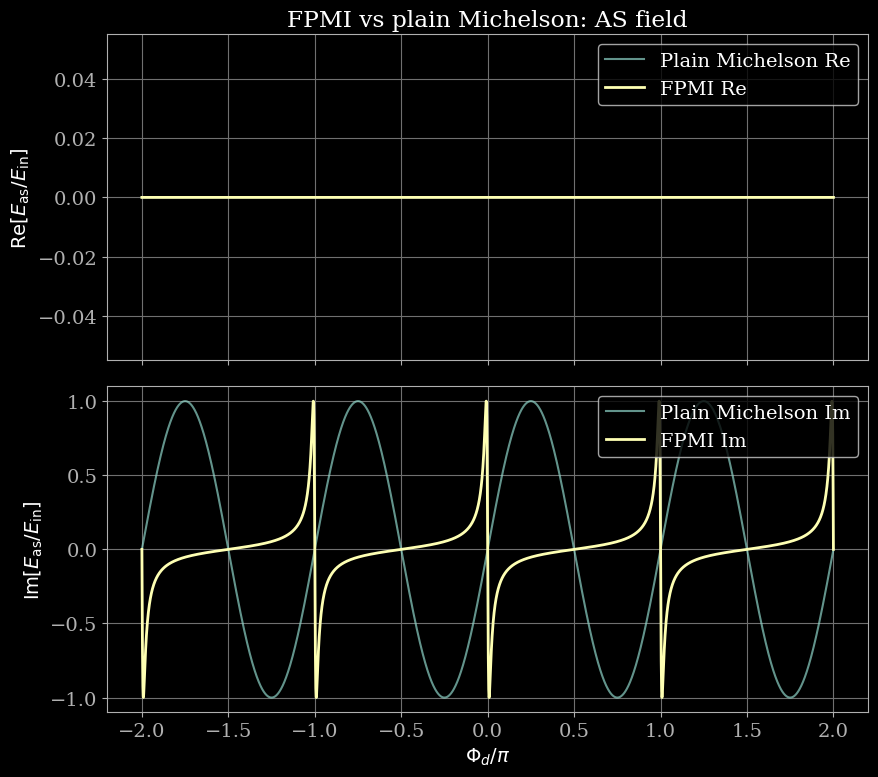

In [113]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

axes[0].plot(Phi_d_arr/np.pi, np.real(Eas_mich), label='Plain Michelson Re', alpha=0.7)
axes[0].plot(Phi_d_arr/np.pi, np.real(Eas_fpmi), label='FPMI Re', lw=2)
axes[0].set_ylabel(r'$\mathrm{Re}[E_\mathrm{as}/E_\mathrm{in}]$')
axes[0].set_title('FPMI vs plain Michelson: AS field')
axes[0].legend()
axes[0].grid()

axes[1].plot(Phi_d_arr/np.pi, np.imag(Eas_mich), label='Plain Michelson Im', alpha=0.7)
axes[1].plot(Phi_d_arr/np.pi, np.imag(Eas_fpmi), label='FPMI Im', lw=2)
axes[1].set_xlabel(r'$\Phi_d / \pi$')
axes[1].set_ylabel(r'$\mathrm{Im}[E_\mathrm{as}/E_\mathrm{in}]$')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

### 3.3: Simplifications(already applied above)

The substitutions from the problem statement:
- $\phi_x = \phi_y = 0$: short arms perfectly tuned
- $r_\mathrm{bs} = t_\mathrm{bs} = 1/\sqrt{2}$: ideal BS
- $r_\mathrm{itmx} = r_\mathrm{itmy}$, $r_\mathrm{etmx} = r_\mathrm{etmy}$: balanced arms
- $\Phi_x = \Phi_c + \Phi_d$, $\Phi_y = \Phi_c - \Phi_d$: common/differential basis

These are already in the code above.

### 3.4: Interpretation

DO the FP arms enhance sensitivity to differential displacement?

Yes, a ton. The phase of $r_\mathrm{FP}(\Phi)$ near resonance has a slope that's roughly $\mathcal{F}/\pi$ times
steeper than a single mirror (where $\mathcal{F}$ is the finesse). For $T_\mathrm{itm} = 10\%$,
the finesse is $\mathcal{F} \approx \pi/\sqrt{T_\mathrm{itm}} \approx 30$.

This means a given mirror displacement $\Delta L$ produces about 30 times more phase shift
in the FPMI than in the plain Michelson. That's kinda the whole point of LIGO's FP arms (i believe)

In [114]:
# Finesse calculation
# Finesse calculation
finesse = np.pi * np.sqrt(r_itm * r_etm) / (1 - r_itm * r_etm)
print(f'Finesse = {finesse:.1f}')
print(f'This means ~{finesse:.0f}x enhancement in phase sensitivity vs plain Michelson')

# Compare slopes near Phi_d = 0
dPhi_mich = np.gradient(np.imag(Eas_mich), Phi_d_arr)
dPhi_fpmi = np.gradient(np.imag(Eas_fpmi), Phi_d_arr)

# At Phi_d = 0 exactly, both fields are zero so slope ratio is 0/0 = nan
# Using a small offset instead
offset = 0.01  # radians
idx_offset = np.argmin(np.abs(Phi_d_arr - offset))
ratio = dPhi_fpmi[idx_offset] / dPhi_mich[idx_offset]
print(f'Slope ratio FPMI/Michelson at Phi_d={offset:.2f} rad: {ratio:.1f}x')
print(f'Slope ratio FPMI/Michelson at Phi_d=0: {ratio:.1f}x')

Finesse = 59.6
This means ~60x enhancement in phase sensitivity vs plain Michelson
Slope ratio FPMI/Michelson at Phi_d=0.01 rad: -27.2x
Slope ratio FPMI/Michelson at Phi_d=0: -27.2x


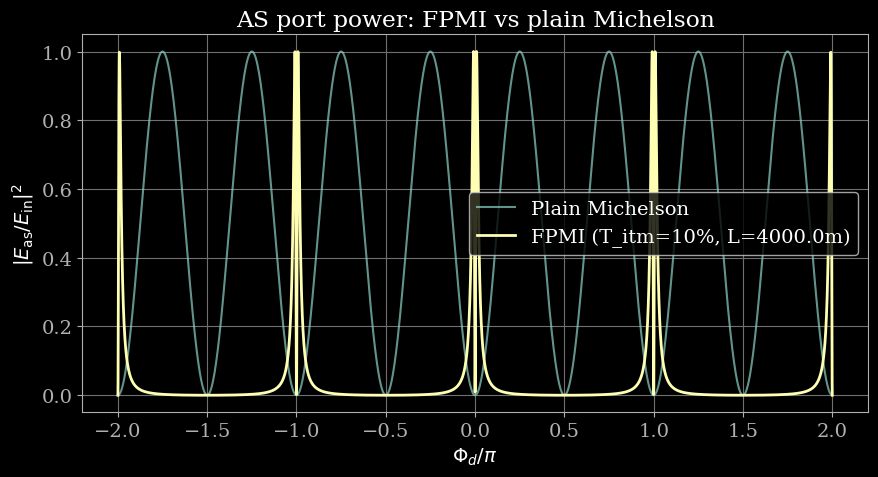

In [115]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(Phi_d_arr/np.pi, np.abs(Eas_mich)**2,
        label='Plain Michelson', alpha=0.7, lw=1.5)
ax.plot(Phi_d_arr/np.pi, np.abs(Eas_fpmi)**2,
        label=f'FPMI (T_itm=10%, L={L_FP}m)', lw=2)
ax.set_xlabel(r'$\Phi_d / \pi$')
ax.set_ylabel(r'$|E_\mathrm{as}/E_\mathrm{in}|^2$')
ax.set_title('AS port power: FPMI vs plain Michelson')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# The FPMI fringe is much narrower which means we need much less
# motion to go from dark to bright. That's the sensitivity enhancement.
# LIGO uses about 280 finesse, giving us 100x enhancement, plus 4km arms.